<a href="https://colab.research.google.com/github/Nikhildongare123/Teen-Social-Media-Usage-Mental-Health/blob/main/data%20analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import pickle


In [ ]:
df=pd.read_csv('/content/Teen_Mental_Health_Dataset.csv')
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,depression_risk
0,19,male,3.8,Instagram,6.5,1.7,2.77,1.2,low,6,6,medium
1,16,male,6.5,Other,5.8,0.6,2.57,0.2,medium,9,7,high
2,17,female,2.9,Other,7.0,1.2,3.04,1.7,high,3,2,low
3,19,female,7.9,TikTok,5.0,1.6,2.21,1.2,medium,10,8,medium
4,15,female,1.2,TikTok,8.8,0.9,3.61,1.9,high,1,2,low


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       2500 non-null   int64  
 1   gender                    2500 non-null   object 
 2   daily_social_media_hours  2500 non-null   float64
 3   platform_usage            2500 non-null   object 
 4   sleep_hours               2500 non-null   float64
 5   screen_time_before_sleep  2500 non-null   float64
 6   academic_performance      2500 non-null   float64
 7   physical_activity         2500 non-null   float64
 8   social_interaction_level  2500 non-null   object 
 9   stress_level              2500 non-null   int64  
 10  anxiety_level             2500 non-null   int64  
 11  depression_risk           2500 non-null   object 
dtypes: float64(5), int64(3), object(4)
memory usage: 234.5+ KB


In [ ]:
df.isnull().sum()

,0
age,0
gender,0
daily_social_media_hours,0
platform_usage,0
sleep_hours,0
screen_time_before_sleep,0
academic_performance,0
physical_activity,0
social_interaction_level,0
stress_level,0


In [ ]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level
count,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,15.978000,4.45804,6.192440,1.714760,2.890944,0.991760,5.596400,5.164800
std,2.003577,2.01693,1.018734,0.716636,0.559553,0.586963,3.039013,3.002473
min,13.000000,1.00000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000
25%,14.000000,2.70000,5.500000,1.100000,2.420000,0.500000,3.000000,2.000000
50%,16.000000,4.40000,6.200000,1.700000,2.880000,1.000000,6.000000,5.000000
75%,18.000000,6.20000,6.900000,2.300000,3.340000,1.500000,8.000000,8.000000
max,19.000000,8.00000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000


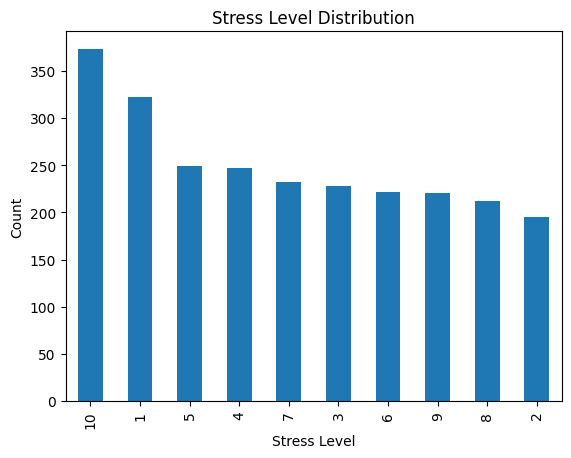

In [ ]:
plt.figure()
df['stress_level'].value_counts().plot(kind='bar')
plt.title("Stress Level Distribution")
plt.xlabel("Stress Level")
plt.ylabel("Count")
plt.show()

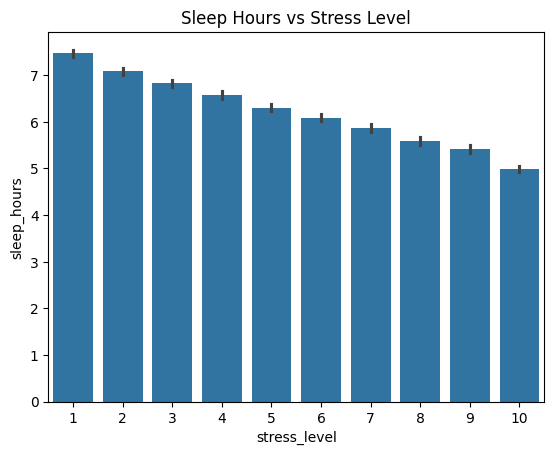

In [ ]:
plt.figure()
sns.barplot(x='stress_level', y='sleep_hours', data=df)
plt.title("Sleep Hours vs Stress Level")
plt.show()

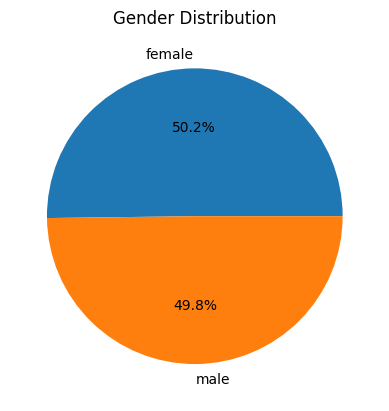

In [ ]:
plt.figure()
df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

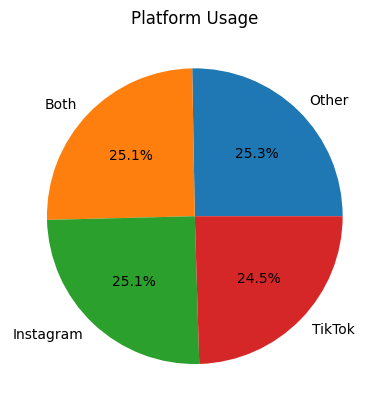

In [ ]:
plt.figure()
df['platform_usage'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Platform Usage")
plt.ylabel("")
plt.show()

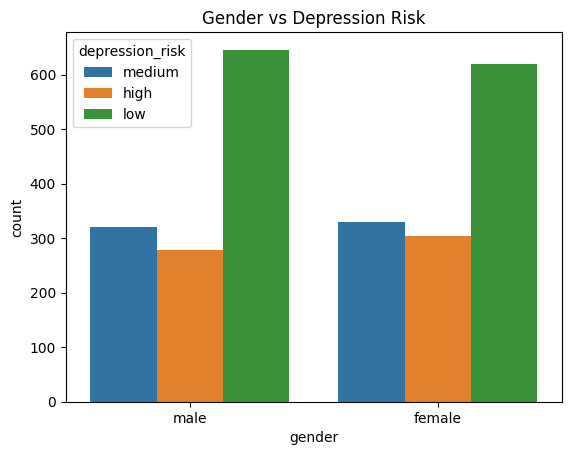

In [ ]:
plt.figure()
sns.countplot(x='gender', hue='depression_risk', data=df)
plt.title("Gender vs Depression Risk")
plt.show()

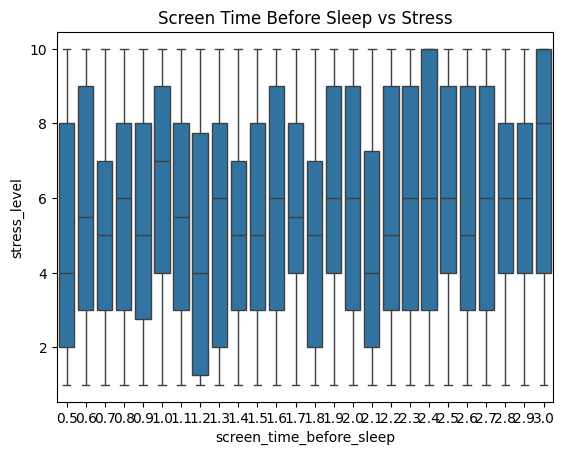

In [ ]:
plt.figure()
sns.boxplot(x='screen_time_before_sleep', y='stress_level', data=df)
plt.title("Screen Time Before Sleep vs Stress")
plt.show()

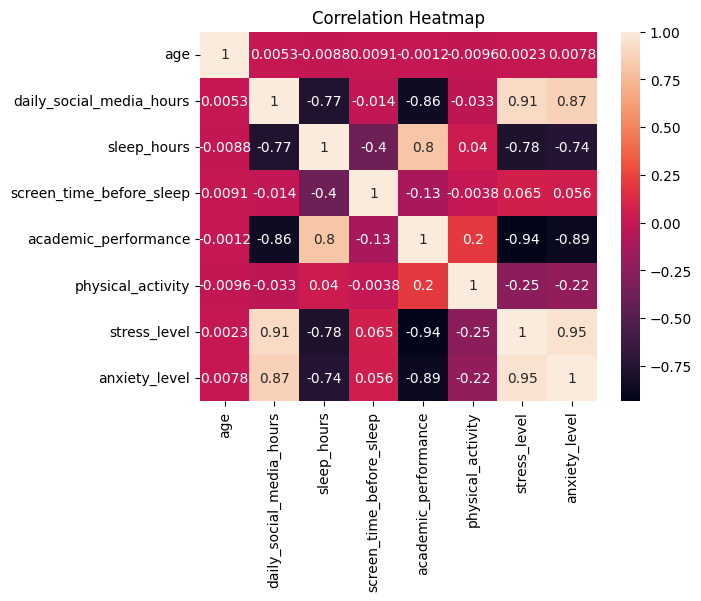

In [ ]:
plt.figure()
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Handle Categorical Data

In [ ]:
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['platform_usage'] = le.fit_transform(df['platform_usage'])
df['social_interaction_level'] = le.fit_transform(df['social_interaction_level'])
df['depression_risk'] = le.fit_transform(df['depression_risk'])

In [ ]:
x  = df.drop('depression_risk', axis=1)
y = df['depression_risk']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42)

In [ ]:
model = RandomForestClassifier(n_estimators=100)
model.fit(x_train, y_train)

RandomForestClassifier()

In [ ]:
y_pred = model.predict(x_test)


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.782
              precision    recall  f1-score   support

           0       0.70      0.99      0.82       112
           1       0.90      0.86      0.88       256
           2       0.62      0.46      0.53       132

    accuracy                           0.78       500
   macro avg       0.74      0.77      0.74       500
weighted avg       0.78      0.78      0.77       500



In [ ]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved again ✅")

Model saved again ✅
